
# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз



In [2]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from IPython.display import display



Завантажив дані: Завантажив файл train.csv.

In [4]:
df = pd.read_csv('train.csv')
print("Розмір датасету:", df.shape)
display(df.head())

Розмір датасету: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


##  EDA — первинний аналіз даних

In [5]:
print("Типи даних:")
display(df.dtypes.value_counts().rename("count").to_frame())

print("\nПерші статистичні характеристики числових ознак:")
display(df.describe().T.head(15))

print("\nПропущені значення — найбільше 20:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(20).to_frame("missing"))

print(f"\nДублікатів рядків: {df.duplicated().sum()}")
print(f"Кількість числових ознак: {df.select_dtypes(include=np.number).shape[1]}")
print(f"Кількість категоріальних ознак: {df.select_dtypes(exclude=np.number).shape[1]}")

Типи даних:


,count
object,43
int64,35
float64,3



Перші статистичні характеристики числових ознак:


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Пропущені значення — найбільше 20:


,missing
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81



Дублікатів рядків: 0
Кількість числових ознак: 38
Кількість категоріальних ознак: 43


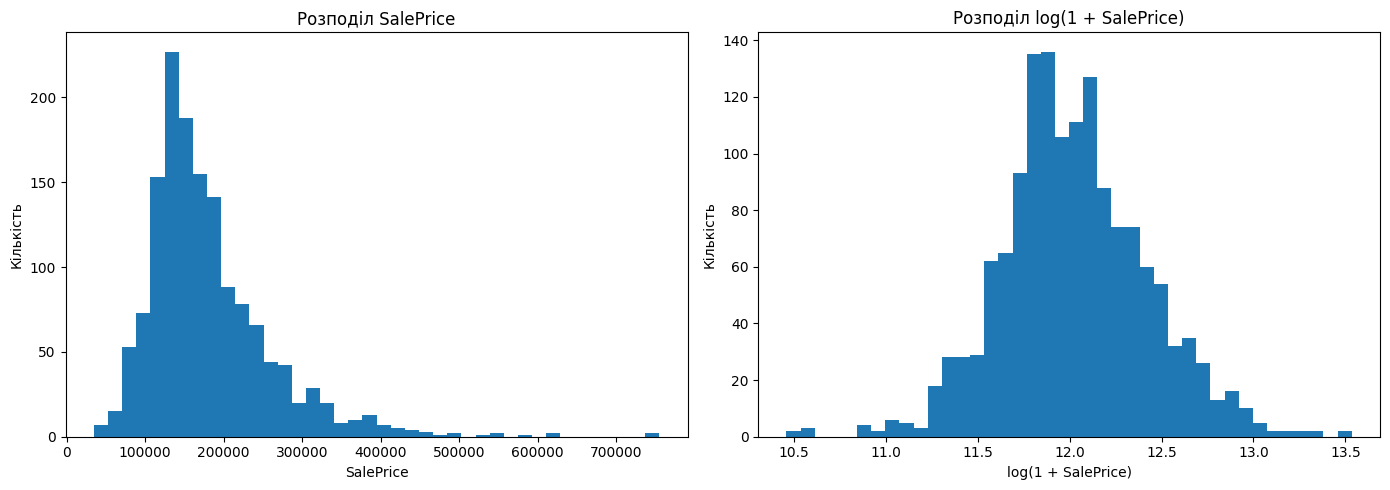

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["SalePrice"], bins=40)
axes[0].set_title("Розподіл SalePrice")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Кількість")

axes[1].hist(np.log1p(df["SalePrice"]), bins=40)
axes[1].set_title("Розподіл log(1 + SalePrice)")
axes[1].set_xlabel("log(1 + SalePrice)")
axes[1].set_ylabel("Кількість")

plt.tight_layout()
plt.show()



### Висновок EDA

`SalePrice` є числовою цільовою змінною, тому задача є задачею регресії. Ames Housing містить як числові, так і категоріальні характеристики будинку. Частина категоріальних полів має пропуски, які в контексті цього датасету можуть означати відсутність певного об'єкта (наприклад, гаража, басейну або підвалу), тому перед кодуванням їх потрібно обробити.

Розподіл ціни має правосторонню асиметрію. Для лінійної регресії в цій роботі ціль не логарифмуємо: замість цього стандартизуємо `y` тільки за параметрами Train для стабільного градієнтного навчання.


##  Train / Validation / Test та контроль Data Leakage

In [7]:

# Спочатку розбиваємо дані, а вже потім навчаємо будь-які параметри preprocessing.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_STATE
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1022, 81)
Validation: (219, 81)
Test: (219, 81)


Теоретична відповідь: чому спочатку split?

Ми спочатку розділяємо дані, тому що масштабування, імпутація, кодування та відбір ознак можуть використовувати статистику датасету.
Якщо, наприклад, обчислити середнє або стандартне відхилення на всіх даних до розбиття, інформація з Validation/Test потрапить у процес навчання. Це називається **Data Leakage** - витік інформації з даних, які повинні залишатися невідомими під час навчання.

In [10]:
numeric_candidates = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_candidates = [c for c in numeric_candidates if c not in ["SalePrice", "Id"]]

train_numeric = train_df[numeric_candidates].copy()

# Заповнюємо пропуски медіанами, обчисленими ТІЛЬКИ на Train.
train_medians = train_numeric.median()
train_numeric_imputed = train_numeric.fillna(train_medians)

corr = train_numeric_imputed.corrwith(train_df["SalePrice"]).abs().sort_values(ascending=False)

print("Найсильніші абсолютні кореляції з SalePrice (Train):")
display(corr.head(15).to_frame("abs_pearson_corr"))

# Обираємо 8 найінформативніших числових ознак.
selected_numeric = corr.head(8).index.tolist()

print("Обрані числові ознаки:")
print(selected_numeric)

Найсильніші абсолютні кореляції з SalePrice (Train):


,abs_pearson_corr
OverallQual,0.784720
GrLivArea,0.689238
GarageCars,0.642689
GarageArea,0.621937
TotalBsmtSF,0.590017
1stFlrSF,0.583132
FullBath,0.549164
TotRmsAbvGrd,0.519634
YearBuilt,0.512206
YearRemodAdd,0.512190


Обрані числові ознаки:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd']


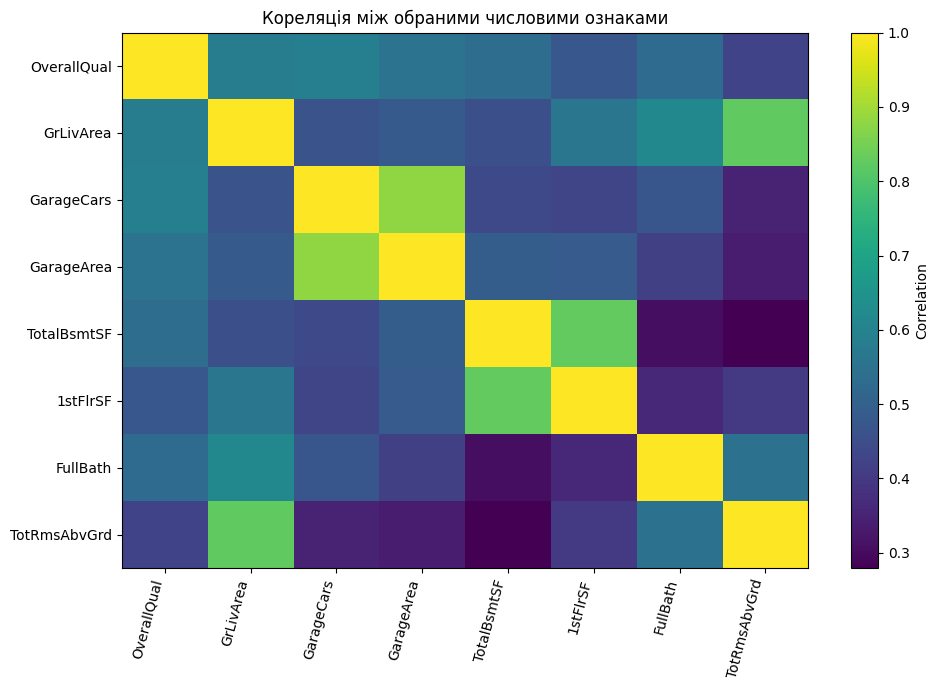

In [11]:

corr_matrix = train_numeric_imputed[selected_numeric].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(selected_numeric)), selected_numeric, rotation=75, ha="right")
plt.yticks(range(len(selected_numeric)), selected_numeric)
plt.title("Кореляція між обраними числовими ознаками")
plt.tight_layout()
plt.show()


## Кодування категорій

In [8]:
# Додаємо дві категоріальні ознаки.
# One-Hot Encoding не створює штучного порядку між категоріями.
selected_categorical = ["Neighborhood", "KitchenQual"]

# Параметри категоріального preprocessing вивчаються тільки на Train.
cat_train = train_df[selected_categorical].copy()

for col in selected_categorical:
    mode = cat_train[col].mode(dropna=True)
    fill_value = mode.iloc[0] if len(mode) else "Missing"
    cat_train[col] = cat_train[col].fillna(fill_value)

cat_train_ohe = pd.get_dummies(cat_train, columns=selected_categorical, dtype=float)

# Запам'ятовуємо набір категорій Train.
ohe_columns = cat_train_ohe.columns.tolist()

print("Кількість One-Hot ознак:", len(ohe_columns))
display(cat_train_ohe.head())

Кількість One-Hot ознак: 29


,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,...,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1452,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
435,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



### Теоретична відповідь: 
При One-Hot Encoding ми фіксуємо словник категорій на Train. Якщо на Validation/Test з'явиться категорія, якої не було в Train, для неї не створюється нова колонка. Рядок буде приведений до колонок Train, а невідоме значення фактично матиме нульові значення для відомих dummy-колонок.
Це захищає від зміни розмірності матриці ознак та від витоку інформації з Validation/Test.


In [12]:

def prepare_features(frame, fit=False):
    numeric = frame[selected_numeric].copy()

    if fit:
        medians = numeric.median()
    else:
        medians = train_medians[selected_numeric]

    numeric = numeric.fillna(medians)

    # Статистика масштабування буде обчислена окремо нижче тільки на Train.
    categorical = frame[selected_categorical].copy()
    for col in selected_categorical:
        fill_value = cat_train[col].mode(dropna=True).iloc[0]
        categorical[col] = categorical[col].fillna(fill_value)

    categorical = pd.get_dummies(categorical, columns=selected_categorical, dtype=float)
    categorical = categorical.reindex(columns=ohe_columns, fill_value=0.0)

    X = pd.concat([numeric.reset_index(drop=True), categorical.reset_index(drop=True)], axis=1)
    return X.astype(float)

X_train_raw = prepare_features(train_df, fit=True)
X_val_raw = prepare_features(val_df)
X_test_raw = prepare_features(test_df)

y_train = train_df["SalePrice"].to_numpy(dtype=float)
y_val = val_df["SalePrice"].to_numpy(dtype=float)
y_test = test_df["SalePrice"].to_numpy(dtype=float)

# Масштабування X: параметри ТІЛЬКИ Train.
X_mean = X_train_raw.mean(axis=0).to_numpy()
X_std = X_train_raw.std(axis=0).to_numpy()
X_std[X_std == 0] = 1.0

X_train = (X_train_raw.to_numpy() - X_mean) / X_std
X_val = (X_val_raw.to_numpy() - X_mean) / X_std
X_test = (X_test_raw.to_numpy() - X_mean) / X_std

# Масштабування target для стабільного GD.
y_mean = y_train.mean()
y_std = y_train.std()

y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std
y_test_s = (y_test - y_mean) / y_std

print("Матриця Train:", X_train.shape)
print("Матриця Validation:", X_val.shape)
print("Матриця Test:", X_test.shape)


Матриця Train: (1022, 37)
Матриця Validation: (219, 37)
Матриця Test: (219, 37)


##  Лінійна регресія 


In [13]:
class LinearRegressionNumpy:
    def __init__(self, n_features, seed=42):
        rng = np.random.default_rng(seed)
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0

    def predict(self, X):
        return X @ self.w + self.b

    @staticmethod
    def mse(y_true, y_pred):
        error = y_pred - y_true
        return np.mean(error ** 2)

    def gradients(self, X, y):
        # Повністю векторизовано: немає циклу по прикладах.
        error = self.predict(X) - y
        grad_w = (2.0 / X.shape[0]) * (X.T @ error)
        grad_b = 2.0 * np.mean(error)
        return grad_w, grad_b

    def update(self, grad_w, grad_b, learning_rate):
        self.w -= learning_rate * grad_w
        self.b -= learning_rate * grad_b

## BGD

In [14]:
def train_batch_gd(X, y, lr=0.05, epochs=300, seed=42):
    model = LinearRegressionNumpy(X.shape[1], seed=seed)
    history = []

    for epoch in range(epochs):
        grad_w, grad_b = model.gradients(X, y)
        model.update(grad_w, grad_b, lr)

        cost = model.mse(y, model.predict(X))
        history.append(cost)

    return model, np.array(history)

batch_model, batch_history = train_batch_gd(
    X_train, y_train_s, lr=0.05, epochs=300
)

print("Фінальний Train Cost:", batch_history[-1])

Фінальний Train Cost: 0.18960590328196078


## SGD and Mini  - batch BGD

In [15]:

def train_sgd(X, y, lr=0.005, epochs=80, seed=42):
    model = LinearRegressionNumpy(X.shape[1], seed=seed)
    rng = np.random.default_rng(seed)
    history = []

    for epoch in range(epochs):
        indices = rng.permutation(X.shape[0])

        # Для SGD оновлення виконується після одного прикладу.
        # Градієнт для одного прикладу все одно обчислюється
        # векторизовано через матричні операції.
        for idx in indices:
            Xi = X[idx:idx+1]
            yi = y[idx:idx+1]
            grad_w, grad_b = model.gradients(Xi, yi)
            model.update(grad_w, grad_b, lr)

        history.append(model.mse(y, model.predict(X)))

    return model, np.array(history)


def train_minibatch_gd(X, y, lr=0.02, batch_size=32, epochs=120, seed=42):
    model = LinearRegressionNumpy(X.shape[1], seed=seed)
    rng = np.random.default_rng(seed)
    history = []

    for epoch in range(epochs):
        indices = rng.permutation(X.shape[0])

        for start in range(0, X.shape[0], batch_size):
            batch_idx = indices[start:start + batch_size]
            Xb = X[batch_idx]
            yb = y[batch_idx]

            grad_w, grad_b = model.gradients(Xb, yb)
            model.update(grad_w, grad_b, lr)

        history.append(model.mse(y, model.predict(X)))

    return model, np.array(history)


sgd_model, sgd_history = train_sgd(
    X_train, y_train_s, lr=0.005, epochs=80
)

mini_model, mini_history = train_minibatch_gd(
    X_train, y_train_s, lr=0.02, batch_size=32, epochs=120
)

print("SGD final cost:", sgd_history[-1])
print("Mini-batch final cost:", mini_history[-1])


SGD final cost: 8.76080448215587e+149
Mini-batch final cost: 0.1927464887463356


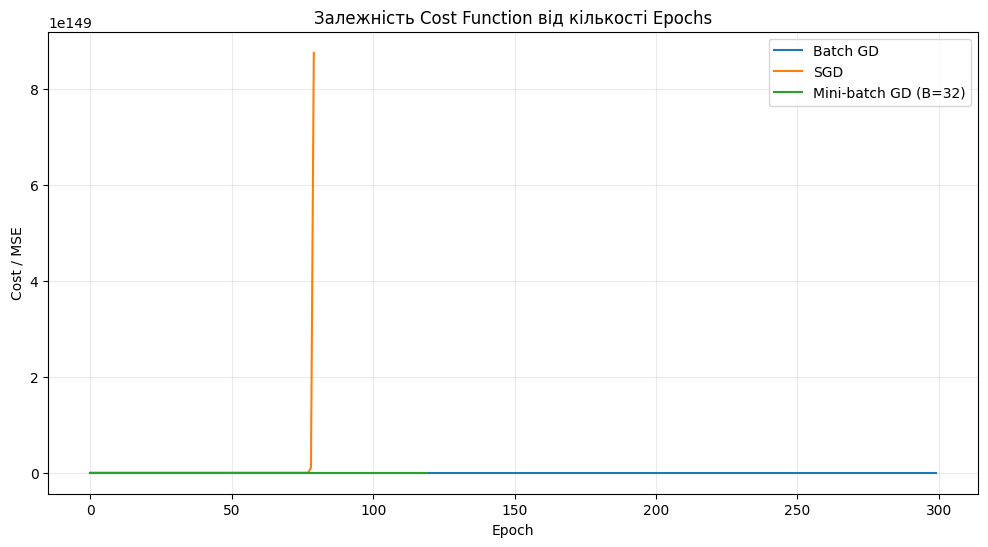

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(batch_history, label="Batch GD")
plt.plot(sgd_history, label="SGD")
plt.plot(mini_history, label="Mini-batch GD (B=32)")
plt.xlabel("Epoch")
plt.ylabel("Cost / MSE")
plt.title("Залежність Cost Function від кількості Epochs")
plt.legend()
plt.grid(alpha=0.25)
plt.show()



### Аналіз графіка

- **Batch GD** використовує весь Train для одного оновлення, тому його траєкторія зазвичай найгладша та найбільш стабільна.
- **SGD** оновлює ваги після кожного прикладу, тому Cost Function має найбільші коливання.
- **Mini-batch GD** займає проміжне положення: менше шуму, ніж SGD, і швидші/частіші оновлення, ніж Batch GD.
- Зменшення batch size зазвичай збільшує шум градієнта, а збільшення batch size робить оцінку градієнта стабільнішою, але одне оновлення стає дорожчим.
- Занадто великий `learning rate` може викликати коливання або розбіжність; занадто малий - повільну збіжність.


##  R^2 для Train / Validation / Test

In [17]:

def r2_score_numpy(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot

def inverse_y(y_scaled):
    return y_scaled * y_std + y_mean

models = {
    "Batch GD": batch_model,
    "SGD": sgd_model,
    "Mini-batch GD": mini_model
}

rows = []
for name, model in models.items():
    for split_name, X, y in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        pred_scaled = model.predict(X)
        pred = inverse_y(pred_scaled)
        rows.append({
            "Model": name,
            "Split": split_name,
            "R2": r2_score_numpy(y, pred)
        })

r2_table = pd.DataFrame(rows)
display(r2_table.pivot(index="Model", columns="Split", values="R2"))


Split,Test,Train,Validation
Model,,,
Batch GD,8.183522e-01,8.103941e-01,8.790991e-01
Mini-batch GD,8.065422e-01,8.072535e-01,8.744634e-01
SGD,-3.232237e+150,-8.760804e+149,-1.028047e+146



### Теоретична інтерпретація R^2

\[
R^2 = 1 - \frac{\sum(y_i-\hat y_i)^2}
{\sum(y_i-\bar y)^2}
\]

R^2 показує, яку частку варіації цільової змінної пояснює модель відносно базового прогнозу середнім значенням.

- `R^2 = 1` - ідеальне відтворення Train/Test значень.
- `R^2 = 0` - модель не краща за прогноз середнім значенням у сенсі цієї метрики.
- `R^2 < 0` можливий, якщо помилки моделі більші за помилки базового прогнозу середнім.

Якщо R^2 на Train значно вищий, ніж на Test, це може свідчити про перенавчання. Якщо значення близькі, узагальнення моделі є стабільнішим.


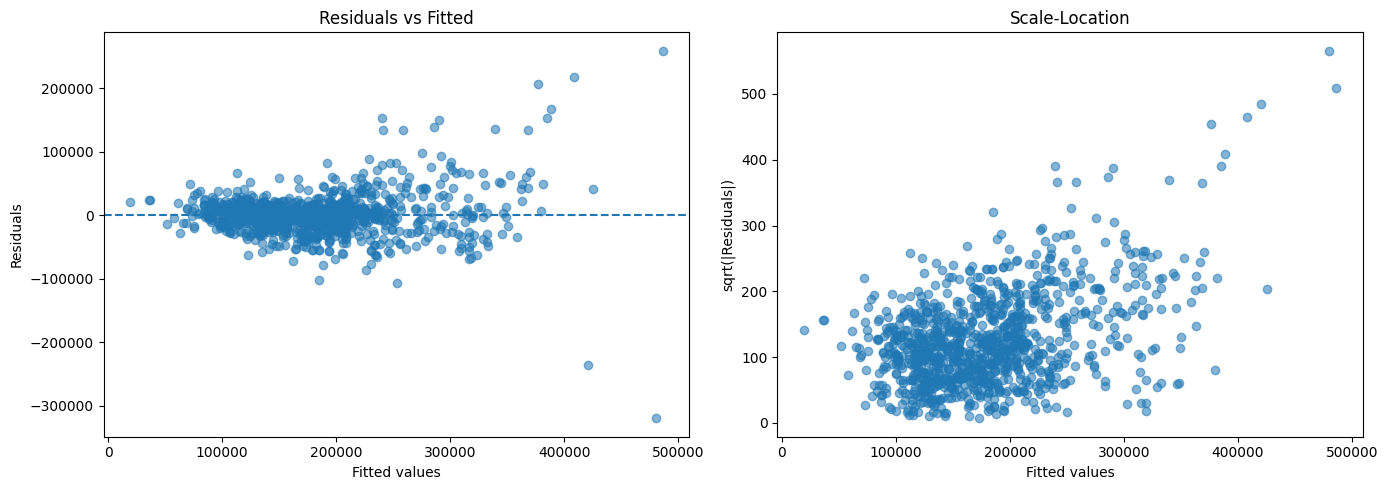

In [18]:

# Для статистичного аналізу беремо Mini-batch модель.
final_model = mini_model

y_pred_train = inverse_y(final_model.predict(X_train))
residuals = y_train - y_pred_train
fitted = y_pred_train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted, residuals, alpha=0.55)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

scale_location = np.sqrt(np.abs(residuals))
axes[1].scatter(fitted, scale_location, alpha=0.55)
axes[1].set_title("Scale-Location")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("sqrt(|Residuals|)")

plt.tight_layout()
plt.show()


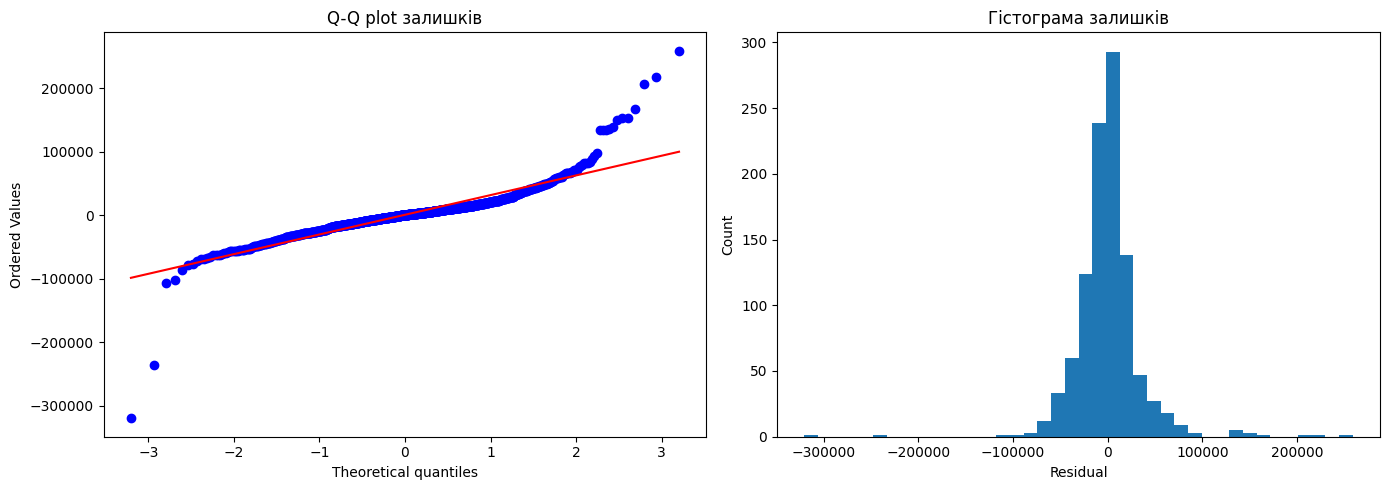

Shapiro-Wilk statistic = 0.8288
Shapiro-Wilk p-value = 1.10725e-31


In [19]:

# Q-Q plot та гістограма залишків
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot залишків")

axes[1].hist(residuals, bins=40)
axes[1].set_title("Гістограма залишків")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

shapiro_sample = residuals
if len(shapiro_sample) > 5000:
    rng = np.random.default_rng(RANDOM_STATE)
    shapiro_sample = rng.choice(shapiro_sample, size=5000, replace=False)

shapiro_stat, shapiro_p = stats.shapiro(shapiro_sample)

print(f"Shapiro-Wilk statistic = {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value = {shapiro_p:.6g}")



### Інтерпретація статистичних припущень

**1. Лінійність.**  
На `Residuals vs Fitted` бажано бачити випадкову хмару навколо нульової лінії без вираженої кривої. Якщо присутній систематичний патерн, лінійна форма залежності недостатня.

**2. Нормальність залишків.**  
На Q-Q plot точки повинні приблизно лежати вздовж діагоналі. Shapiro-Wilk перевіряє нульову гіпотезу про нормальність. Для великої вибірки тест дуже чутливий, тому його потрібно інтерпретувати разом із Q-Q plot та гістограмою.

**3. Гомоскедастичність.**  
На Scale-Location бажано, щоб розкид був приблизно однаковим у всьому діапазоні fitted values. Якщо розкид систематично збільшується, є ознаки гетероскедастичності.

**4. Мультиколінеарність.**  
Перевіряємо кореляції та VIF. Сильна залежність між предикторами не обов'язково погіршує прогноз, але може зробити окремі коефіцієнти нестабільними та складнішими для інтерпретації.


##  VIF — перевірка мультиколінеарності

In [20]:

def calculate_vif(X, feature_names):
    Xv = np.asarray(X, dtype=float)
    Xv = np.column_stack([np.ones(Xv.shape[0]), Xv])

    # Кореляційна матриця для числової частини.
    # Для VIF використовуємо inverse correlation matrix.
    X_centered = Xv[:, 1:] - Xv[:, 1:].mean(axis=0)
    stds = X_centered.std(axis=0)
    stds[stds == 0] = 1.0
    corr = np.corrcoef(X_centered / stds, rowvar=False)

    try:
        inv_corr = np.linalg.inv(corr)
        vif = np.diag(inv_corr)
    except np.linalg.LinAlgError:
        vif = np.full(corr.shape[0], np.inf)

    return pd.DataFrame({"feature": feature_names, "VIF": vif})

# VIF для числових ознак, де інтерпретація найпростіша.
vif_table = calculate_vif(
    train_numeric_imputed[selected_numeric].to_numpy(),
    selected_numeric
).sort_values("VIF", ascending=False)

display(vif_table)


,feature,VIF
2,GarageCars,5.012230
3,GarageArea,4.905678
1,GrLivArea,4.698759
5,1stFlrSF,3.755216
4,TotalBsmtSF,3.650741
7,TotRmsAbvGrd,3.292449
0,OverallQual,2.204983
6,FullBath,1.847866



### Висновок щодо мультиколінеарності

Якщо VIF деяких ознак великий, це означає, що вони значною мірою пояснюються іншими предикторами. У такому випадку оцінені коефіцієнти можуть бути чутливими до невеликих змін даних.
Для практичної інтерпретації орієнтуємося не на одну магічну межу, а на сукупність VIF, кореляційної матриці та поведінки коефіцієнтів. У цій роботі основний акцент - на прогнозуванні та демонстрації впливу мультиколінеарності на стабільність параметрів.


##  Поглиблений експеримент A: вплив масштабування

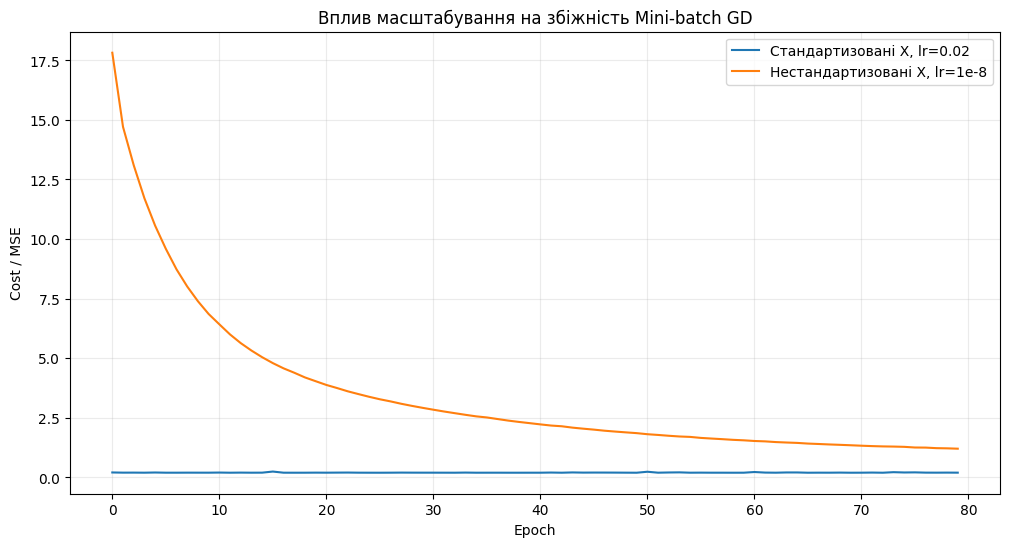

Final cost, scaled: 0.1925393686180864
Final cost, unscaled: 1.198454508084752


In [ ]:

# Порівнюємо Mini-batch GD на:
# 1) стандартизованих ознаках;
# 2) сирих ознаках.
# На сирих даних допустимий learning rate потрібно сильно зменшити, оскільки масштаби LotArea, GrLivArea, YearBuilt тощо дуже різні.

X_train_unscaled = X_train_raw.to_numpy(dtype=float)
X_train_unscaled = np.nan_to_num(X_train_unscaled, nan=0.0, posinf=0.0, neginf=0.0)

scaled_model, scaled_history = train_minibatch_gd(
    X_train, y_train_s, lr=0.02, batch_size=32, epochs=80, seed=42
)

unscaled_model, unscaled_history = train_minibatch_gd(
    X_train_unscaled, y_train_s, lr=1e-8, batch_size=32, epochs=80, seed=42
)

plt.figure(figsize=(12, 6))
plt.plot(scaled_history, label="Стандартизовані X, lr=0.02")
plt.plot(unscaled_history, label="Нестандартизовані X, lr=1e-8")
plt.xlabel("Epoch")
plt.ylabel("Cost / MSE")
plt.title("Вплив масштабування на збіжність Mini-batch GD")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Final cost, scaled:", scaled_history[-1])
print("Final cost, unscaled:", unscaled_history[-1])



### Геометричне пояснення

Без масштабування окремі ознаки мають дуже різні масштаби. Поверхня Cost Function у просторі ваг стає витягнутою: один напрямок може мати набагато більшу кривизну, ніж інший. Через це градієнтний спуск може рухатися зигзагоподібно та вимагати дуже малого learning rate.
Після стандартизації ознаки мають порівнювані масштаби. Поверхня оптимізації стає краще пристосованою до градієнтного руху, тому можна використовувати більший learning rate і отримати швидшу та стабільнішу збіжність.


##  Порівняння коефіцієнтів моделей

In [22]:

coef_table = pd.DataFrame({
    "feature": X_train_raw.columns,
    "Batch_GD": batch_model.w,
    "SGD": sgd_model.w,
    "MiniBatch_GD": mini_model.w
})

coef_table["abs_change_SGD_vs_Batch"] = (
    coef_table["SGD"] - coef_table["Batch_GD"]
).abs()

coef_table["abs_change_Mini_vs_Batch"] = (
    coef_table["MiniBatch_GD"] - coef_table["Batch_GD"]
).abs()

display(
    coef_table.sort_values("abs_change_Mini_vs_Batch", ascending=False).head(15)
)


,feature,Batch_GD,SGD,MiniBatch_GD,abs_change_SGD_vs_Batch,abs_change_Mini_vs_Batch
3,GarageArea,0.023937,3.126822e+72,0.004361,3.126822e+72,0.019576
23,Neighborhood_NoRidge,0.131985,5.656674e+72,0.146920,5.656674e+72,0.014935
33,KitchenQual_Ex,0.144265,2.536944e+72,0.132111,2.536944e+72,0.012154
4,TotalBsmtSF,0.060597,-1.916603e+72,0.049193,1.916603e+72,0.011404
0,OverallQual,0.240342,-3.103947e+72,0.230894,3.103947e+72,0.009448
20,Neighborhood_NAmes,-0.038628,1.198027e+73,-0.031862,1.198027e+73,0.006766
24,Neighborhood_NridgHt,0.106464,5.164784e+72,0.100674,5.164784e+72,0.005791
36,KitchenQual_TA,-0.064085,-5.421027e+71,-0.058655,5.421027e+71,0.005430
1,GrLivArea,0.227584,-2.956331e+72,0.222196,2.956331e+72,0.005388
34,KitchenQual_Fa,-0.018324,-8.303445e+71,-0.013437,8.303445e+71,0.004887



## Висновок:

У роботі виконано повний цикл побудови лінійної регресії на Ames Housing Dataset.

1. Проведено EDA: структура даних, типи ознак, пропуски та розподіл `SalePrice`.
2. Дані спочатку поділено на Train, Validation і Test, що запобігає Data Leakage.
3. Відбір числових ознак виконано тільки на Train за абсолютною кореляцією з `SalePrice`.
4. Категоріальні ознаки `Neighborhood` та `KitchenQual` закодовано One-Hot Encoding; словник категорій формується тільки на Train.
5. Масштабування ознак виконано параметрами, отриманими тільки з Train.
6. Лінійну регресію реалізовано самостійно засобами NumPy: prediction, MSE, градієнти та оновлення параметрів.
7. Реалізовано три способи градієнтного спуску: Batch GD, SGD та Mini-batch GD.
8. Для всіх методів побудовано графіки зміни Cost Function та порівняно їхню стабільність.
9. Обчислено R^2 для Train, Validation та Test.
10. Перевірено лінійність, нормальність залишків, гомоскедастичність і мультиколінеарність.
11. Виконано поглиблений експеримент із впливом масштабування на швидкість збіжності Mini-batch GD.

**Ключовий результат:** правильний preprocessing та масштабування є критично важливими для стабільного градієнтного навчання, а різні варіанти GD мають різний компроміс між стабільністю оцінки градієнта та частотою оновлень.
